# Noisy-by-clean vs teacher/student recovery

This notebook is a package-based worked example for two model-recovery evaluations. It uses small synthetic data so the figures can teach the mechanism without needing the full production pipeline.

By the end, you should be able to:

- read a recovery score matrix row by row;
- explain why lower off-diagonal model-RDM correlation makes recovery easier;
- distinguish direct noisy-by-clean recovery from the stricter teacher/student refit test;
- interpret recovery curves through the underlying score matrices and row margins.

The toy data are intentionally simple. They are meant to make the evaluation logic visible, not to reproduce every production detail.

## Notation and matrix reading guide

Throughout the notebook, rows are the source model and columns are candidate models.

- **RDM**: a vector of pairwise distances among image responses or features.
- **Score**: Spearman correlation between two RDM vectors.
- **Diagonal cell**: the score for the correct source-candidate match.
- **Best off-diagonal**: the strongest wrong candidate in the same row.
- **Margin**: `diagonal score - best off-diagonal score`.
- **Correct recovery**: the diagonal is the largest value in its row.
- **Chance recovery**: `1 / number_of_models`, which is `0.25` here.

In the score-matrix figures, black boxes mark the correct diagonal and row-winner dots mark the candidate that wins that row.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path("/data/home_roth/cstims_share")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cstims.evaluation.computation import (
    compute_all_rdms,
    compute_clean_correlation_matrix,
    compute_discriminability_by_noise_level,
    compute_noised_correlation_matrices,
)
from cstims.evaluation.model_discrimination import model_discriminability
from cstims.evaluation.noise_calibration import (
    multiplier_to_noise_ceiling,
    rdm_noise_std_from_clean,
    response_noise_std_from_mode,
)
from cstims.evaluation.ridge import ridge_ops_for_eval_sets, standardize_from_train
from cstims.rdm_cuda import calculate_correlation_value, get_rdm_vector_np

SEED = 8
rng = np.random.default_rng(SEED)
torch.set_num_threads(4)
device = torch.device("cpu")

MODEL_NAMES = ["A", "B", "C", "D"]
N_MODELS = len(MODEL_NAMES)
BASE_NOISE_CEILING = 0.46
NOISE_MULTS = np.array([0.10, 0.20, 0.50, 1.00, 2.50, 6.40], dtype=float)
RELATIVE_SNR = 1.0 / NOISE_MULTS
METRIC = "correlation"
CORR_TYPE = "spearman"

RANDOM_COLOR = "#C4473D"
SELECTED_COLOR = "#2F6FBB"
NEUTRAL_COLOR = "0.45"
WIN_COLOR = "#111111"
FAIL_COLOR = "#B23A48"
SUBSET_COLORS = {"random": RANDOM_COLOR, "selected": SELECTED_COLOR}

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)


def offdiag_values(matrix: np.ndarray) -> np.ndarray:
    return matrix[~np.eye(matrix.shape[0], dtype=bool)]


def row_margins(matrix: np.ndarray) -> np.ndarray:
    margins = []
    for i in range(matrix.shape[0]):
        margins.append(float(matrix[i, i] - np.max(np.delete(matrix[i], i))))
    return np.asarray(margins, dtype=float)


def row_accuracy(matrix: np.ndarray) -> float:
    winners = np.nanargmax(matrix, axis=1)
    return float(np.mean(winners == np.arange(matrix.shape[0])))


def text_color_for_cell(value: float, vmin: float, vmax: float, cmap_name: str) -> str:
    cmap = plt.get_cmap(cmap_name)
    if vmax <= vmin:
        return "black"
    normed = np.clip((float(value) - vmin) / (vmax - vmin), 0, 1)
    r, g, b, _ = cmap(normed)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.58 else "white"


def label_panel(ax, label: str) -> None:
    ax.text(
        -0.12,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="right",
    )


def add_noise_multiplier_axis(ax) -> None:
    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda snr: 1.0 / np.asarray(snr), lambda mult: 1.0 / np.asarray(mult)),
    )
    secax.set_xscale("log")
    secax.set_xlabel("Noise multiplier")
    secax.tick_params(axis="x", labelsize=8)


def plot_score_matrix(
    ax,
    matrix: np.ndarray,
    title: str,
    x_label: str,
    y_label: str,
    *,
    vmin: float | None = None,
    vmax: float | None = None,
    cmap: str = "viridis",
    show_values: bool = True,
    show_winners: bool = True,
    show_diagonal: bool = True,
):
    matrix = np.asarray(matrix, dtype=float)
    if vmin is None:
        vmin = float(np.nanmin(matrix))
    if vmax is None:
        vmax = float(np.nanmax(matrix))
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(N_MODELS), MODEL_NAMES)
    ax.set_yticks(range(N_MODELS), MODEL_NAMES)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(-0.5, N_MODELS - 0.5)
    ax.set_ylim(N_MODELS - 0.5, -0.5)

    for i in range(N_MODELS):
        if show_diagonal:
            ax.add_patch(
                mpatches.Rectangle(
                    (i - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.2,
                    zorder=3,
                )
            )
        winner = int(np.nanargmax(matrix[i]))
        for j in range(N_MODELS):
            if show_values:
                ax.text(
                    j,
                    i,
                    f"{matrix[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold" if j == i else "normal",
                    color=text_color_for_cell(matrix[i, j], vmin, vmax, cmap),
                    zorder=4,
                )
        if show_winners:
            recovered = winner == i
            ax.scatter(
                [winner + 0.30],
                [i - 0.30],
                marker="o",
                s=44,
                color=WIN_COLOR if recovered else FAIL_COLOR,
                edgecolor="white",
                linewidth=0.7,
                zorder=5,
            )
    return im


def plot_recovery_curves(ax_acc, ax_margin, results_by_subset, *, title_prefix: str) -> None:
    for subset, linestyle in [("random", "--"), ("selected", "-")]:
        color = SUBSET_COLORS[subset]
        accuracy = results_by_subset[subset]["accuracy"]
        margin = results_by_subset[subset]["margin"]
        ax_acc.plot(RELATIVE_SNR, accuracy, marker="o", color=color, linestyle=linestyle, label=subset)
        ax_margin.plot(RELATIVE_SNR, margin, marker="o", color=color, linestyle=linestyle, label=subset)
    for ax in [ax_acc, ax_margin]:
        ax.set_xscale("log")
        ax.grid(True, alpha=0.25)
        ax.set_xlabel("Relative SNR (1 / noise multiplier)")
        add_noise_multiplier_axis(ax)
    ax_acc.set_title(f"{title_prefix}: recovery accuracy")
    ax_acc.set_ylabel("Recovery accuracy")
    ax_acc.set_ylim(0, 1.04)
    ax_acc.axhline(1 / N_MODELS, color=NEUTRAL_COLOR, linestyle=":", linewidth=1)
    ax_acc.text(0.02, 1 / N_MODELS + 0.035, "chance = 1/4", transform=ax_acc.get_yaxis_transform(), ha="left", color=NEUTRAL_COLOR)
    ax_acc.legend(frameon=False, title="image set")
    ax_margin.set_title(f"{title_prefix}: mean row margin")
    ax_margin.set_ylabel("Diagonal - best off-diagonal")
    ax_margin.axhline(0, color="0.2", linewidth=0.8)


print(f"Using cstims package from {SRC_DIR}")

Using cstims package from /data/home_roth/cstims_share/src


## Method overview

Both methods produce a score matrix, but the meaning of a cell is different.

**Method 1: noisy-by-clean recovery is fixed-template matching.** A clean model RDM is noised, then matched directly against the clean candidate RDMs:

```text
score[i, j] = Spearman corr(noisy RDM of model i, clean RDM of model j)
```

Nothing is learned for a score-matrix cell. Candidate `j` is just a fixed clean RDM template.

**Method 2: teacher/student recovery is supervised refit plus held-out RDM matching.** A teacher model generates noisy response targets. Each candidate student gets a ridge readout fit to those teacher targets on refit images, then the fitted student's held-out predictions are converted to an RDM and scored against the teacher's held-out noisy RDM:

```text
fit W[i, j] on refit images:     student_j features -> noisy teacher_i responses
score[i, j] = Spearman corr(RDM(student_j held-out predictions), noisy teacher_i held-out RDM)
```

A teacher/student cell therefore includes a learned mapping `W[i, j]`. This is why the method is stricter: a wrong student can sometimes fit the noisy teacher well enough to beat the teacher's own student row.

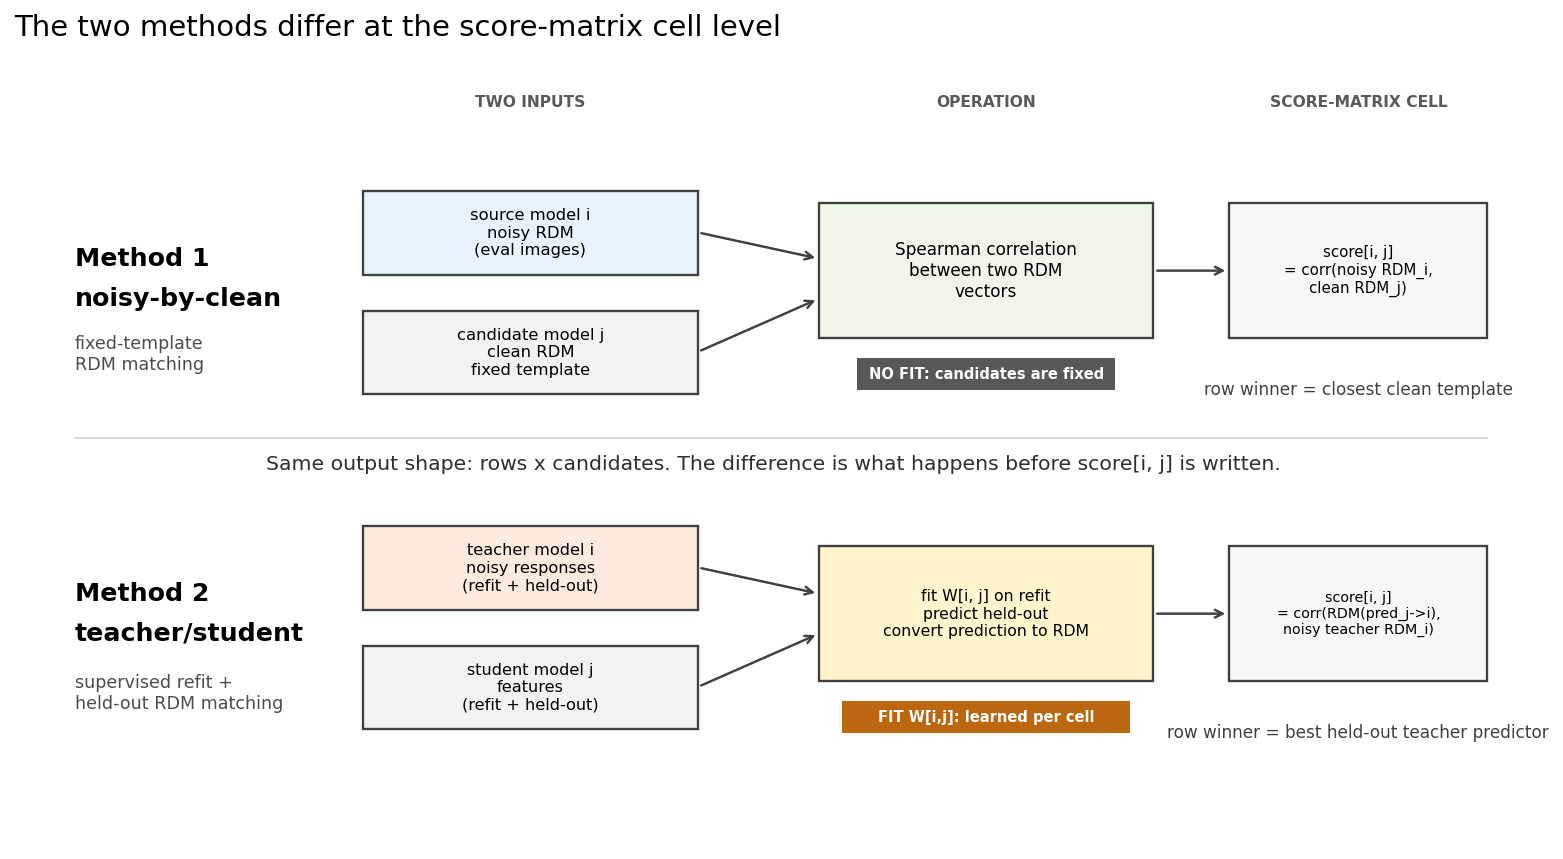

In [2]:
fig, ax = plt.subplots(figsize=(14.0, 7.4))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


def add_box(ax, x, y, w, h, text, *, facecolor, edgecolor="0.25", fontsize=8.8, weight="normal"):
    rect = mpatches.Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, fontweight=weight)
    return rect


def add_tag(ax, x, y, w, text, *, color):
    rect = mpatches.Rectangle((x, y), w, 0.040, facecolor=color, edgecolor="none", alpha=0.94)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + 0.020, text, ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")


def add_arrow(ax, start, end, *, color="0.25"):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", linewidth=1.25, color=color))

# Shared column positions.
x_inputs = 0.23
w_inputs = 0.22
x_op = 0.53
w_op = 0.22
x_score = 0.80
w_score = 0.17
h_input = 0.105
h_op = 0.17

ax.text(x_inputs + w_inputs / 2, 0.925, "TWO INPUTS", ha="center", fontsize=8, color="0.35", fontweight="bold")
ax.text(x_op + w_op / 2, 0.925, "OPERATION", ha="center", fontsize=8, color="0.35", fontweight="bold")
ax.text(x_score + w_score / 2, 0.925, "SCORE-MATRIX CELL", ha="center", fontsize=8, color="0.35", fontweight="bold")

# Method 1.
y_top = 0.64
ax.text(0.04, y_top + 0.095, "Method 1", fontsize=13, fontweight="bold", va="center")
ax.text(0.04, y_top + 0.045, "noisy-by-clean", fontsize=13, fontweight="bold", va="center")
ax.text(0.04, y_top - 0.025, "fixed-template\nRDM matching", fontsize=9, color="0.30", va="center")

add_box(ax, x_inputs, y_top + 0.075, w_inputs, h_input, "source model i\nnoisy RDM\n(eval images)", facecolor="#E9F2FF", fontsize=8.4)
add_box(ax, x_inputs, y_top - 0.075, w_inputs, h_input, "candidate model j\nclean RDM\nfixed template", facecolor="#F2F2F2", fontsize=8.4)
add_box(ax, x_op, y_top - 0.005, w_op, h_op, "Spearman correlation\nbetween two RDM\nvectors", facecolor="#EEF7EA", fontsize=8.7)
add_box(ax, x_score, y_top - 0.005, w_score, h_op, "score[i, j]\n= corr(noisy RDM_i,\nclean RDM_j)", facecolor="#F7F7F7", fontsize=7.7)
add_arrow(ax, (x_inputs + w_inputs, y_top + 0.128), (x_op, y_top + 0.095))
add_arrow(ax, (x_inputs + w_inputs, y_top - 0.022), (x_op, y_top + 0.045))
add_arrow(ax, (x_op + w_op, y_top + 0.080), (x_score, y_top + 0.080))
add_tag(ax, x_op + 0.025, y_top - 0.070, 0.17, "NO FIT: candidates are fixed", color="#4D4D4D")
ax.text(x_score + w_score / 2, y_top - 0.075, "row winner = closest clean template", ha="center", fontsize=8.7, color="0.25")

# Divider and contrast sentence.
ax.plot([0.04, 0.97], [0.51, 0.51], color="0.85", linewidth=1)
ax.text(
    0.50,
    0.49,
    "Same output shape: rows x candidates. The difference is what happens before score[i, j] is written.",
    ha="center",
    va="top",
    fontsize=10.5,
    color="0.18",
)

# Method 2.
y_bot = 0.20
ax.text(0.04, y_bot + 0.115, "Method 2", fontsize=13, fontweight="bold", va="center")
ax.text(0.04, y_bot + 0.065, "teacher/student", fontsize=13, fontweight="bold", va="center")
ax.text(0.04, y_bot - 0.010, "supervised refit +\nheld-out RDM matching", fontsize=9, color="0.30", va="center")

add_box(ax, x_inputs, y_bot + 0.095, w_inputs, h_input, "teacher model i\nnoisy responses\n(refit + held-out)", facecolor="#FFEBDD", fontsize=8.3)
add_box(ax, x_inputs, y_bot - 0.055, w_inputs, h_input, "student model j\nfeatures\n(refit + held-out)", facecolor="#F2F2F2", fontsize=8.3)
add_box(ax, x_op, y_bot + 0.005, w_op, h_op, "fit W[i, j] on refit\npredict held-out\nconvert prediction to RDM", facecolor="#FFF4CC", fontsize=8.1)
add_box(ax, x_score, y_bot + 0.005, w_score, h_op, "score[i, j]\n= corr(RDM(pred_j->i),\nnoisy teacher RDM_i)", facecolor="#F7F7F7", fontsize=7.3)
add_arrow(ax, (x_inputs + w_inputs, y_bot + 0.148), (x_op, y_bot + 0.115))
add_arrow(ax, (x_inputs + w_inputs, y_bot - 0.002), (x_op, y_bot + 0.065))
add_arrow(ax, (x_op + w_op, y_bot + 0.090), (x_score, y_bot + 0.090))
add_tag(ax, x_op + 0.015, y_bot - 0.060, 0.19, "FIT W[i,j]: learned per cell", color="#B85C00")
ax.text(x_score + w_score / 2, y_bot - 0.065, "row winner = best held-out teacher predictor", ha="center", fontsize=8.7, color="0.25")

ax.set_title("The two methods differ at the score-matrix cell level", loc="left", fontsize=15)
plt.show()

## Toy data: what selected is supposed to change

The toy data has four models (`A-D`) and two image sets:

- **Random images**: all models are mostly driven by the same shared stimulus axis. Their RDMs therefore look similar, which creates large off-diagonal correlations.
- **Selected images**: each model has a stronger model-specific stimulus axis. Their RDMs become more distinct, which lowers off-diagonal correlations.

The toy feature equation is:

```text
features(model, subset) = shared axis + subset_strength * model-specific axis
```

The models are not changed between random and selected. The selected images simply expose differences that were already present in the models.

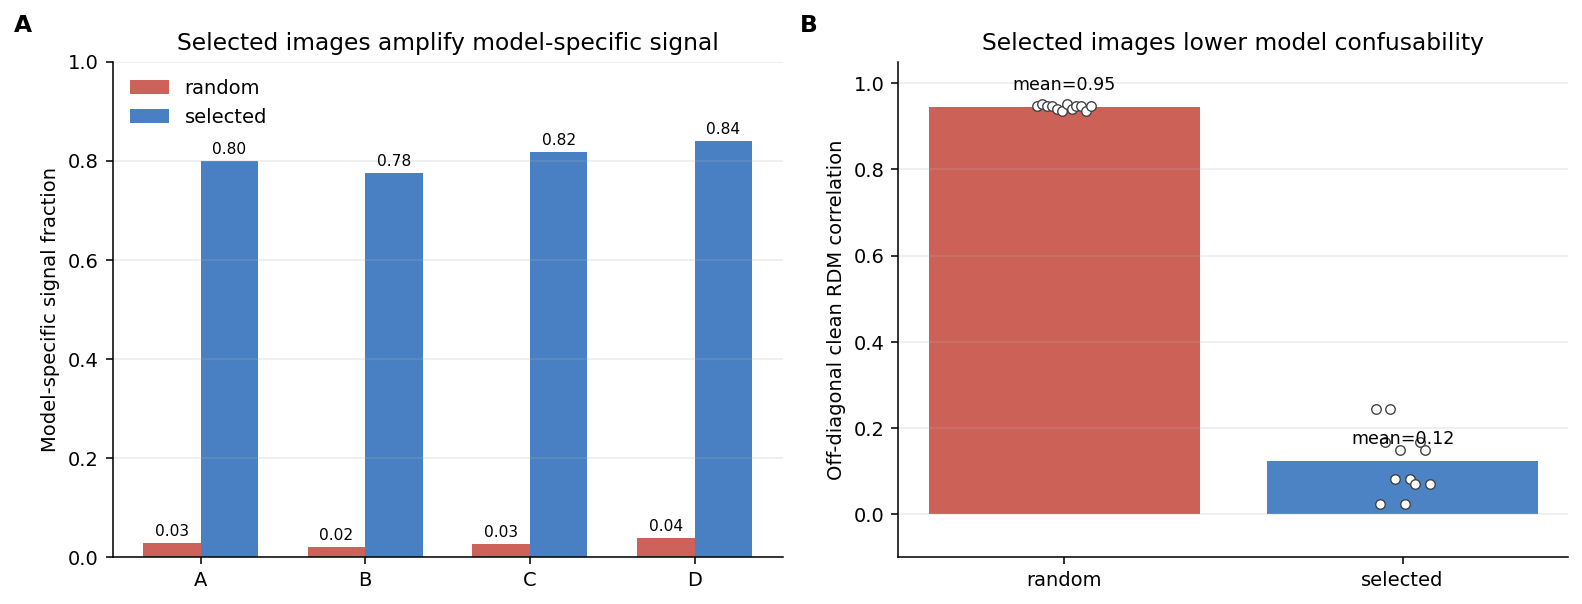

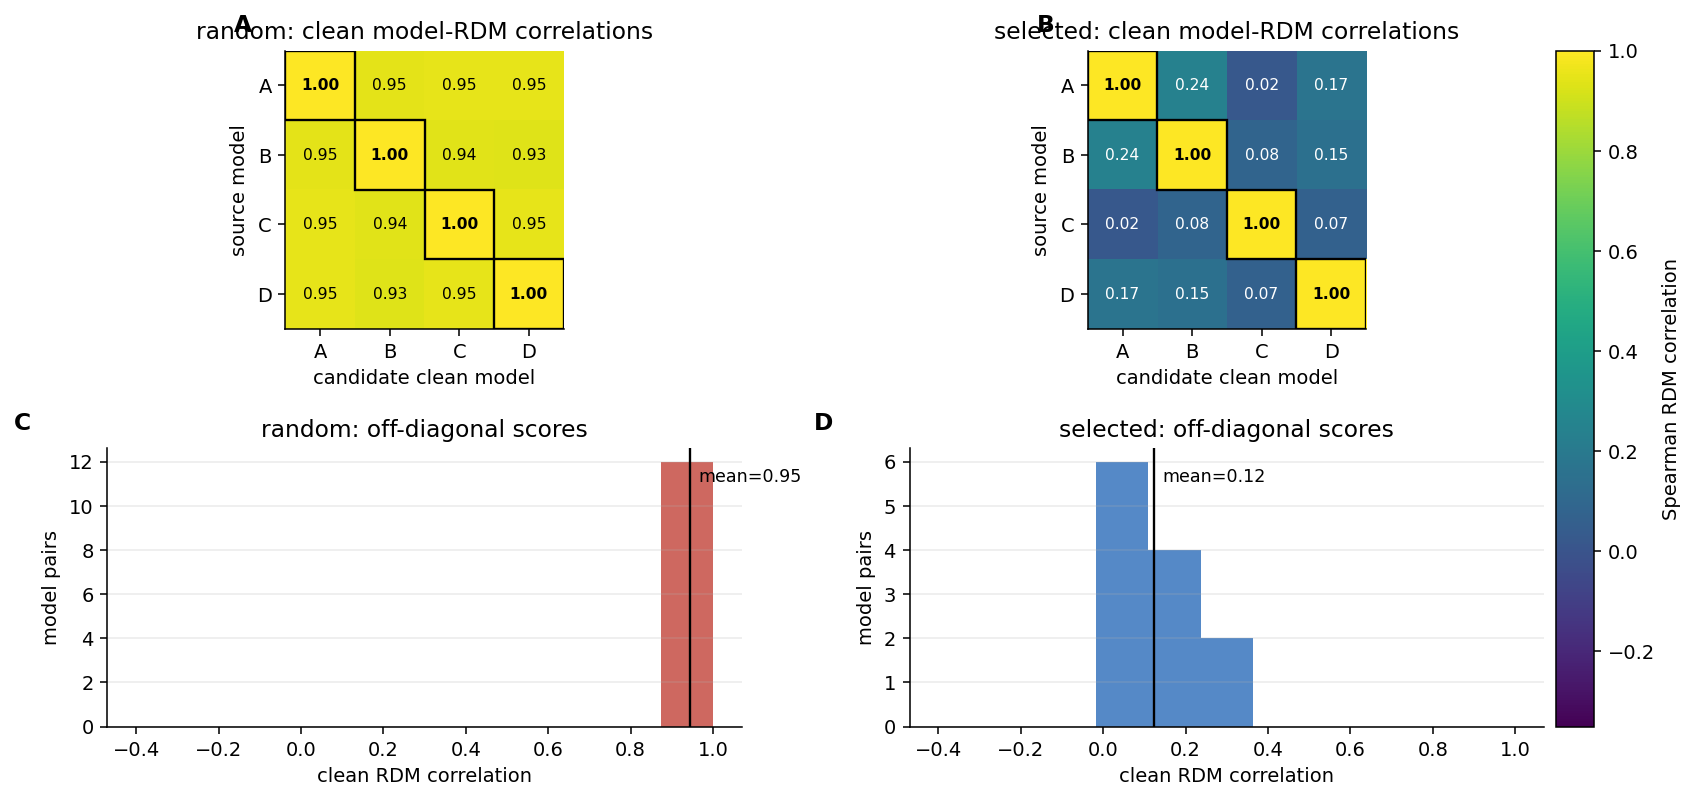

In [3]:
n_eval = 28
n_refit_train = 90
n_refit_val = 30
n_refit = n_refit_train + n_refit_val
common_dim = 5
unique_dim = 5
feature_dim = 16

shared_w = rng.normal(0.0, 1.0, size=(common_dim, feature_dim)).astype(np.float32)
model_common_w = {name: rng.normal(0.0, 0.25, size=(common_dim, feature_dim)).astype(np.float32) for name in MODEL_NAMES}
model_unique_w = {name: rng.normal(0.0, 1.0, size=(unique_dim, feature_dim)).astype(np.float32) for name in MODEL_NAMES}

common = {
    "random": rng.normal(0.0, 1.0, size=(n_eval, common_dim)).astype(np.float32),
    "selected": rng.normal(0.0, 1.0, size=(n_eval, common_dim)).astype(np.float32),
    "refit": rng.normal(0.0, 1.0, size=(n_refit, common_dim)).astype(np.float32),
}
unique = {
    split: {
        name: rng.normal(0.0, 1.0, size=(n_eval if split != "refit" else n_refit, unique_dim)).astype(np.float32)
        for name in MODEL_NAMES
    }
    for split in ["random", "selected", "refit"]
}
unique_scale = {"random": 0.20, "selected": 2.20, "refit": 1.00}

toy_features = {split: {} for split in ["random", "selected", "refit"]}
variance_rows = []
for split in toy_features:
    for name in MODEL_NAMES:
        shared_part = common[split] @ (shared_w + model_common_w[name])
        unique_part = unique_scale[split] * (unique[split][name] @ model_unique_w[name])
        x = shared_part + unique_part
        standardized = standardize_from_train(x)[0]
        toy_features[split][name] = standardized
        if split in ["random", "selected"]:
            variance_rows.append(
                {
                    "subset": split,
                    "model": name,
                    "shared_var": float(np.var(shared_part)),
                    "model_specific_var": float(np.var(unique_part)),
                }
            )

rdms_by_subset = {}
clean_matrices = {}
for subset in ["random", "selected"]:
    feature_tensors = {
        name: torch.as_tensor(toy_features[subset][name], dtype=torch.float32, device=device)
        for name in MODEL_NAMES
    }
    rdms = compute_all_rdms(feature_tensors, [METRIC])[METRIC]
    rdms_by_subset[subset] = rdms
    clean_matrices[subset] = compute_clean_correlation_matrix(rdms, CORR_TYPE).numpy()

signal_fractions = {"random": [], "selected": []}
for subset in ["random", "selected"]:
    for name in MODEL_NAMES:
        row = next(row for row in variance_rows if row["subset"] == subset and row["model"] == name)
        signal_fractions[subset].append(row["model_specific_var"] / (row["shared_var"] + row["model_specific_var"]))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)
ax = axes[0]
x = np.arange(len(MODEL_NAMES))
width = 0.35
bars_random = ax.bar(x - width / 2, signal_fractions["random"], width, color=RANDOM_COLOR, alpha=0.85, label="random")
bars_selected = ax.bar(x + width / 2, signal_fractions["selected"], width, color=SELECTED_COLOR, alpha=0.88, label="selected")
ax.set_xticks(x, MODEL_NAMES)
ax.set_ylim(0, 1)
ax.set_ylabel("Model-specific signal fraction")
ax.set_title("Selected images amplify model-specific signal")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
for bars in [bars_random, bars_selected]:
    ax.bar_label(bars, labels=[f"{bar.get_height():.2f}" for bar in bars], padding=2, fontsize=8)
label_panel(ax, "A")

ax = axes[1]
summary_x = np.arange(2)
means = [offdiag_values(clean_matrices[subset]).mean() for subset in ["random", "selected"]]
ax.bar(summary_x, means, color=[RANDOM_COLOR, SELECTED_COLOR], alpha=0.86)
for idx, subset in enumerate(["random", "selected"]):
    vals = offdiag_values(clean_matrices[subset])
    jitter = np.linspace(-0.08, 0.08, len(vals))
    ax.scatter(np.full_like(vals, idx, dtype=float) + jitter, vals, s=24, color="white", edgecolor="0.25", linewidth=0.7, zorder=3)
    ax.text(idx, means[idx] + 0.04, f"mean={means[idx]:.2f}", ha="center", fontsize=9)
ax.set_xticks(summary_x, ["random", "selected"])
ax.set_ylim(-0.1, 1.05)
ax.set_ylabel("Off-diagonal clean RDM correlation")
ax.set_title("Selected images lower model confusability")
ax.grid(axis="y", alpha=0.25)
label_panel(ax, "B")
plt.show()

fig = plt.figure(figsize=(12.0, 5.6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06])
heat_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
hist_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
cbar_ax = fig.add_subplot(gs[:, 2])

for panel, ax, subset in zip(["A", "B"], heat_axes, ["random", "selected"]):
    im = plot_score_matrix(
        ax,
        clean_matrices[subset],
        f"{subset}: clean model-RDM correlations",
        "candidate clean model",
        "source model",
        vmin=-0.35,
        vmax=1.0,
        cmap="viridis",
        show_winners=False,
    )
    label_panel(ax, panel)
fig.colorbar(im, cax=cbar_ax, label="Spearman RDM correlation")

for panel, ax, subset in zip(["C", "D"], hist_axes, ["random", "selected"]):
    vals = offdiag_values(clean_matrices[subset])
    ax.hist(vals, bins=np.linspace(-0.4, 1.0, 12), color=SUBSET_COLORS[subset], alpha=0.82)
    ax.axvline(vals.mean(), color="black", linewidth=1.2)
    ax.text(vals.mean() + 0.02, ax.get_ylim()[1] * 0.88, f"mean={vals.mean():.2f}", fontsize=9)
    ax.set_title(f"{subset}: off-diagonal scores")
    ax.set_xlabel("clean RDM correlation")
    ax.set_ylabel("model pairs")
    ax.grid(axis="y", alpha=0.25)
    label_panel(ax, panel)
plt.show()

**Figure takeaway.** In the random set, off-diagonal clean RDM correlations are almost as high as the diagonal, so every model looks like every other model. In the selected set, the diagonal remains high but off-diagonal correlations drop, which creates room for correct recovery after noise is added.

## Method 1: noisy-by-clean recovery

Look at the score matrix row by row:

- the row is the model that generated the noisy RDM observation;
- the columns are candidate clean model RDMs;
- the diagonal cell is the correct match;
- recovery is correct when the diagonal is the largest cell in its row.

The selected set should help because its clean off-diagonal correlations are lower. After noise is added, random rows can still score highly against the wrong clean model; selected rows should keep a clearer diagonal.

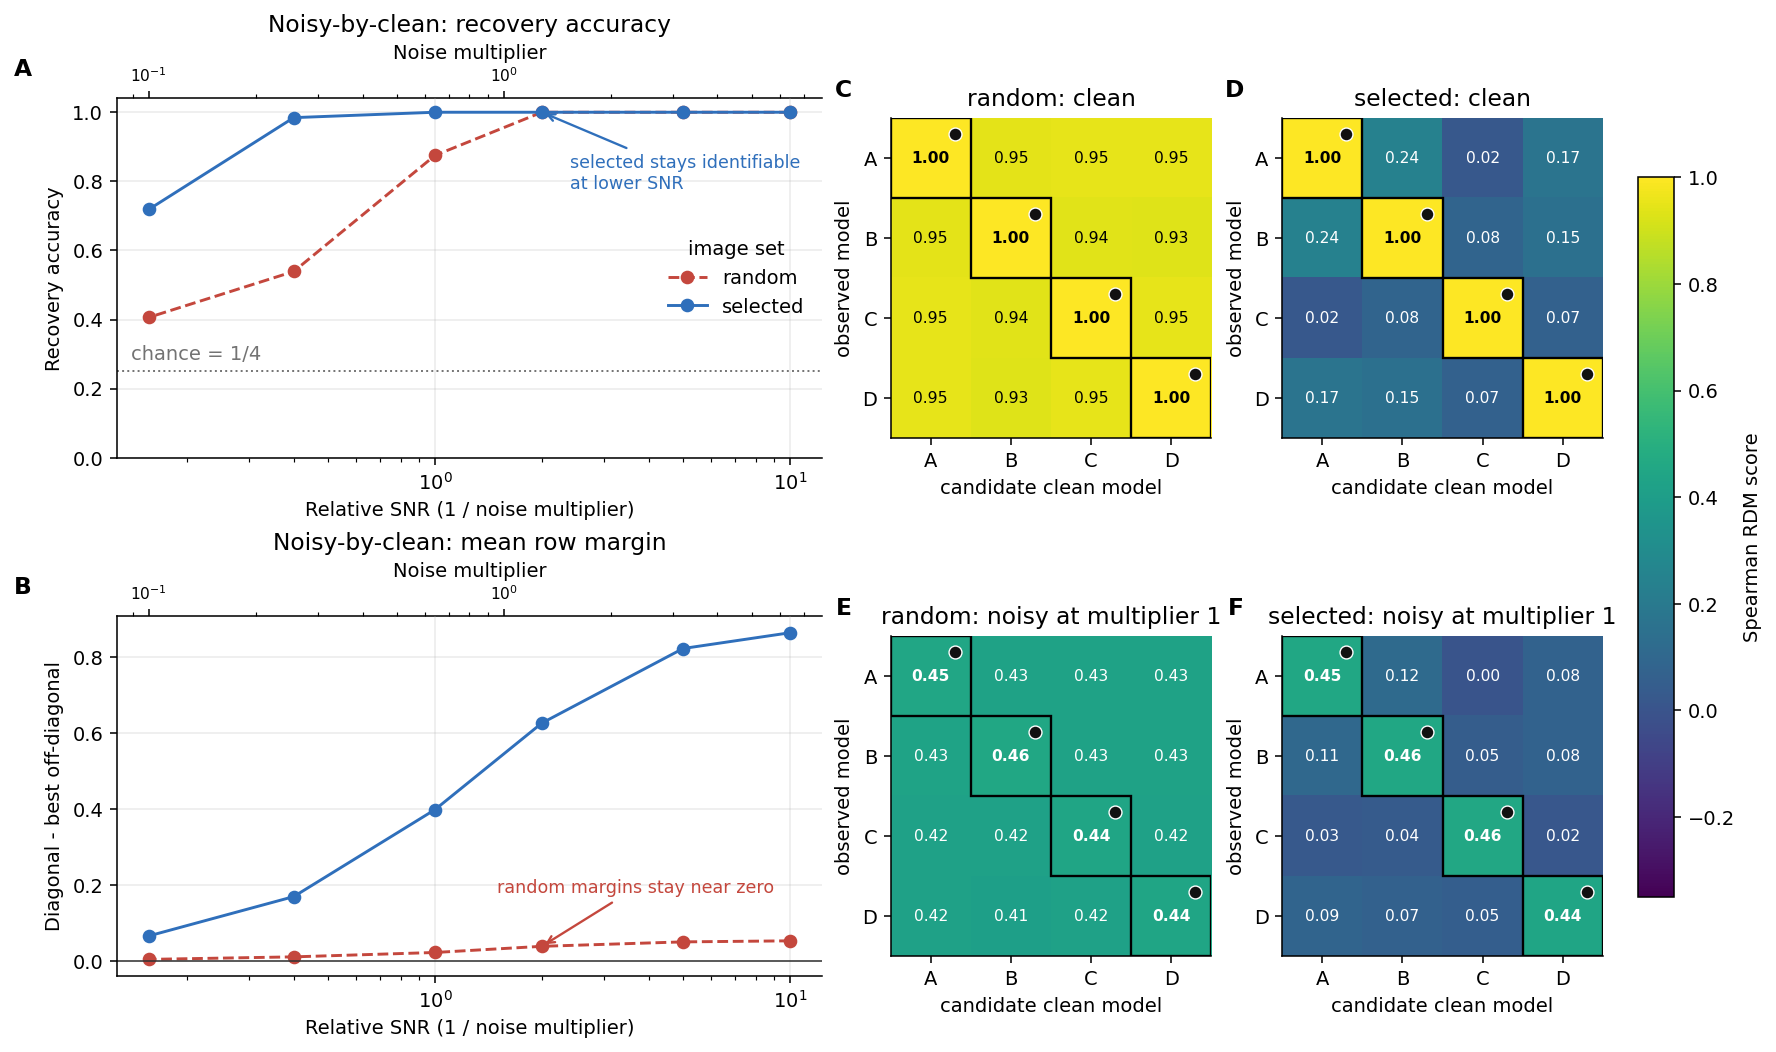

In [4]:
nbc_results = {}
nbc_plot_results = {}
nbc_score_matrices = {}
nbc_clean_matrices = {}
nbc_base_noise_stds = {}
for subset in ["random", "selected"]:
    rdms = rdms_by_subset[subset]
    base_noise_stds = torch.tensor(
        [rdm_noise_std_from_clean(rdm.detach().cpu().numpy(), BASE_NOISE_CEILING, 1.0) for rdm in rdms],
        dtype=torch.float32,
        device=device,
    ).reshape(N_MODELS, 1)
    nbc_base_noise_stds[subset] = base_noise_stds
    nbc_results[subset] = compute_discriminability_by_noise_level(
        rdms=rdms,
        noise_stds=base_noise_stds,
        n_noise_samples=32,
        noise_level_multipliers=NOISE_MULTS,
        corr_type=CORR_TYPE,
        orientation="noisy_by_clean",
        seed=100 + (subset == "selected"),
    )
    nbc_plot_results[subset] = {
        "accuracy": 1.0 - nbc_results[subset]["multiclass_error_probability"],
        "margin": nbc_results[subset]["mean_pairwise_margin"],
    }
    nbc_clean_matrices[subset] = compute_clean_correlation_matrix(rdms, CORR_TYPE).numpy()
    nbc_score_matrices[subset] = compute_noised_correlation_matrices(
        rdms,
        base_noise_stds,
        CORR_TYPE,
        n_noise_samples=32,
        noise_multiplier=1.0,
        orientation="noisy_by_clean",
        generator=torch.Generator(device=device).manual_seed(900 + (subset == "selected")),
    ).mean(dim=0).cpu().numpy()

fig = plt.figure(figsize=(12.6, 7.4), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1.1, 1.1, 1.0, 1.0])
ax_acc = fig.add_subplot(gs[0, :2])
ax_margin = fig.add_subplot(gs[1, :2])
mat_axes = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]

plot_recovery_curves(ax_acc, ax_margin, nbc_plot_results, title_prefix="Noisy-by-clean")
ax_acc.annotate(
    "selected stays identifiable\nat lower SNR",
    xy=(RELATIVE_SNR[2], nbc_plot_results["selected"]["accuracy"][2]),
    xytext=(RELATIVE_SNR[2] * 1.2, 0.78),
    arrowprops=dict(arrowstyle="->", color=SELECTED_COLOR, linewidth=1.2),
    color=SELECTED_COLOR,
    fontsize=9,
)
ax_margin.annotate(
    "random margins stay near zero",
    xy=(RELATIVE_SNR[2], nbc_plot_results["random"]["margin"][2]),
    xytext=(RELATIVE_SNR[2] * 0.75, 0.18),
    arrowprops=dict(arrowstyle="->", color=RANDOM_COLOR, linewidth=1.2),
    color=RANDOM_COLOR,
    fontsize=9,
)
label_panel(ax_acc, "A")
label_panel(ax_margin, "B")

matrix_specs = [
    ("random", "clean", nbc_clean_matrices["random"]),
    ("selected", "clean", nbc_clean_matrices["selected"]),
    ("random", "noisy at multiplier 1", nbc_score_matrices["random"]),
    ("selected", "noisy at multiplier 1", nbc_score_matrices["selected"]),
]
for panel, ax, (subset, kind, matrix) in zip(["C", "D", "E", "F"], mat_axes, matrix_specs):
    im = plot_score_matrix(
        ax,
        matrix,
        f"{subset}: {kind}",
        "candidate clean model",
        "observed model",
        vmin=-0.35,
        vmax=1.0,
        cmap="viridis",
        show_winners=True,
    )
    label_panel(ax, panel)
fig.colorbar(im, ax=mat_axes, shrink=0.82, label="Spearman RDM score")
plt.show()

### One-row worked example

A full score matrix is just four row-wise classification problems. The next figure pulls out the `A` row from the noisy-by-clean score matrices at noise multiplier `1.0`. The margin is the vertical gap between the diagonal bar and the tallest wrong-candidate bar.

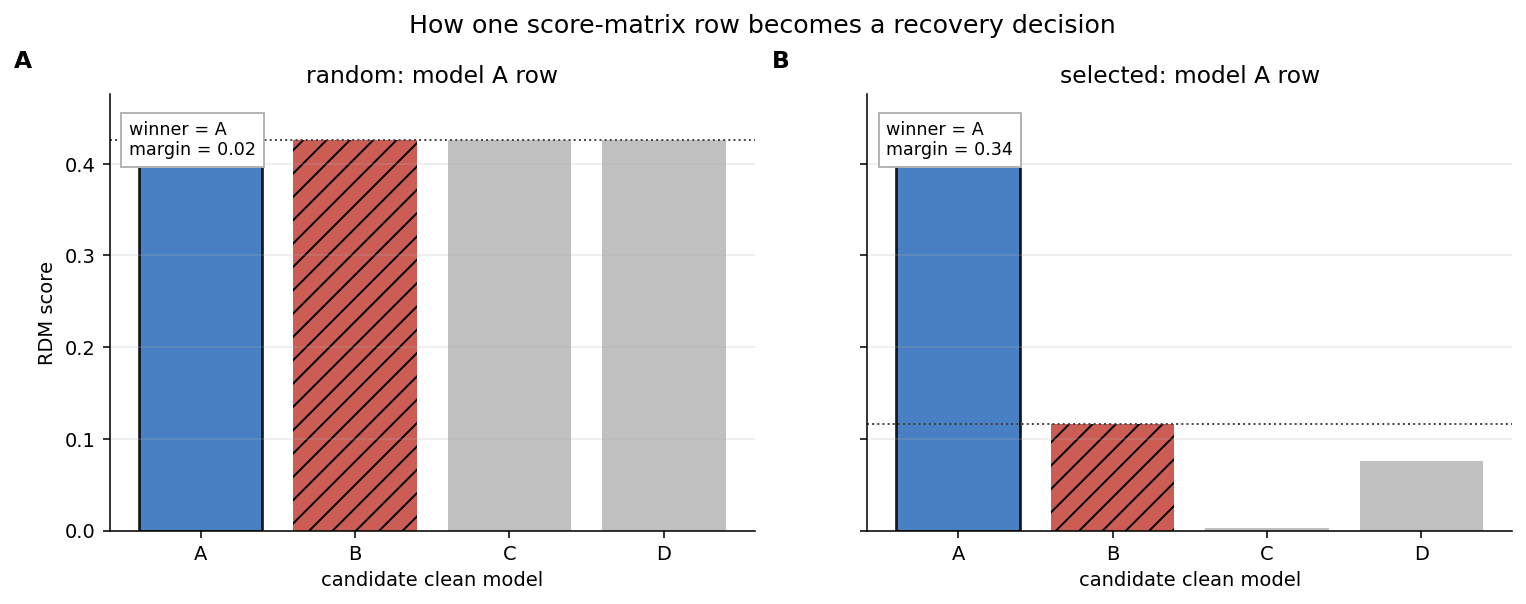

In [5]:
row_idx = 0
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True, sharey=True)
for panel, ax, subset in zip(["A", "B"], axes, ["random", "selected"]):
    matrix = nbc_score_matrices[subset]
    scores = matrix[row_idx]
    winner = int(np.nanargmax(scores))
    best_off_idx = int(np.argmax(np.where(np.arange(N_MODELS) == row_idx, -np.inf, scores)))
    margin = float(scores[row_idx] - scores[best_off_idx])
    colors = ["0.72"] * N_MODELS
    colors[row_idx] = SELECTED_COLOR
    colors[best_off_idx] = RANDOM_COLOR if best_off_idx != row_idx else SELECTED_COLOR
    bars = ax.bar(MODEL_NAMES, scores, color=colors, alpha=0.88)
    bars[row_idx].set_edgecolor("black")
    bars[row_idx].set_linewidth(1.4)
    bars[best_off_idx].set_hatch("//")
    ax.axhline(scores[best_off_idx], color="0.25", linestyle=":", linewidth=1)
    ax.text(
        0.03,
        0.94,
        f"winner = {MODEL_NAMES[winner]}\nmargin = {margin:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="0.7", pad=4),
    )
    ax.set_title(f"{subset}: model A row")
    ax.set_xlabel("candidate clean model")
    ax.grid(axis="y", alpha=0.25)
    label_panel(ax, panel)
axes[0].set_ylabel("RDM score")
fig.suptitle("How one score-matrix row becomes a recovery decision", fontsize=13)
plt.show()

### Noise progression

The recovery curve summarizes many score matrices. This progression shows the same idea directly: as noise increases, row winners become less reliable when the off-diagonal scores are already high.

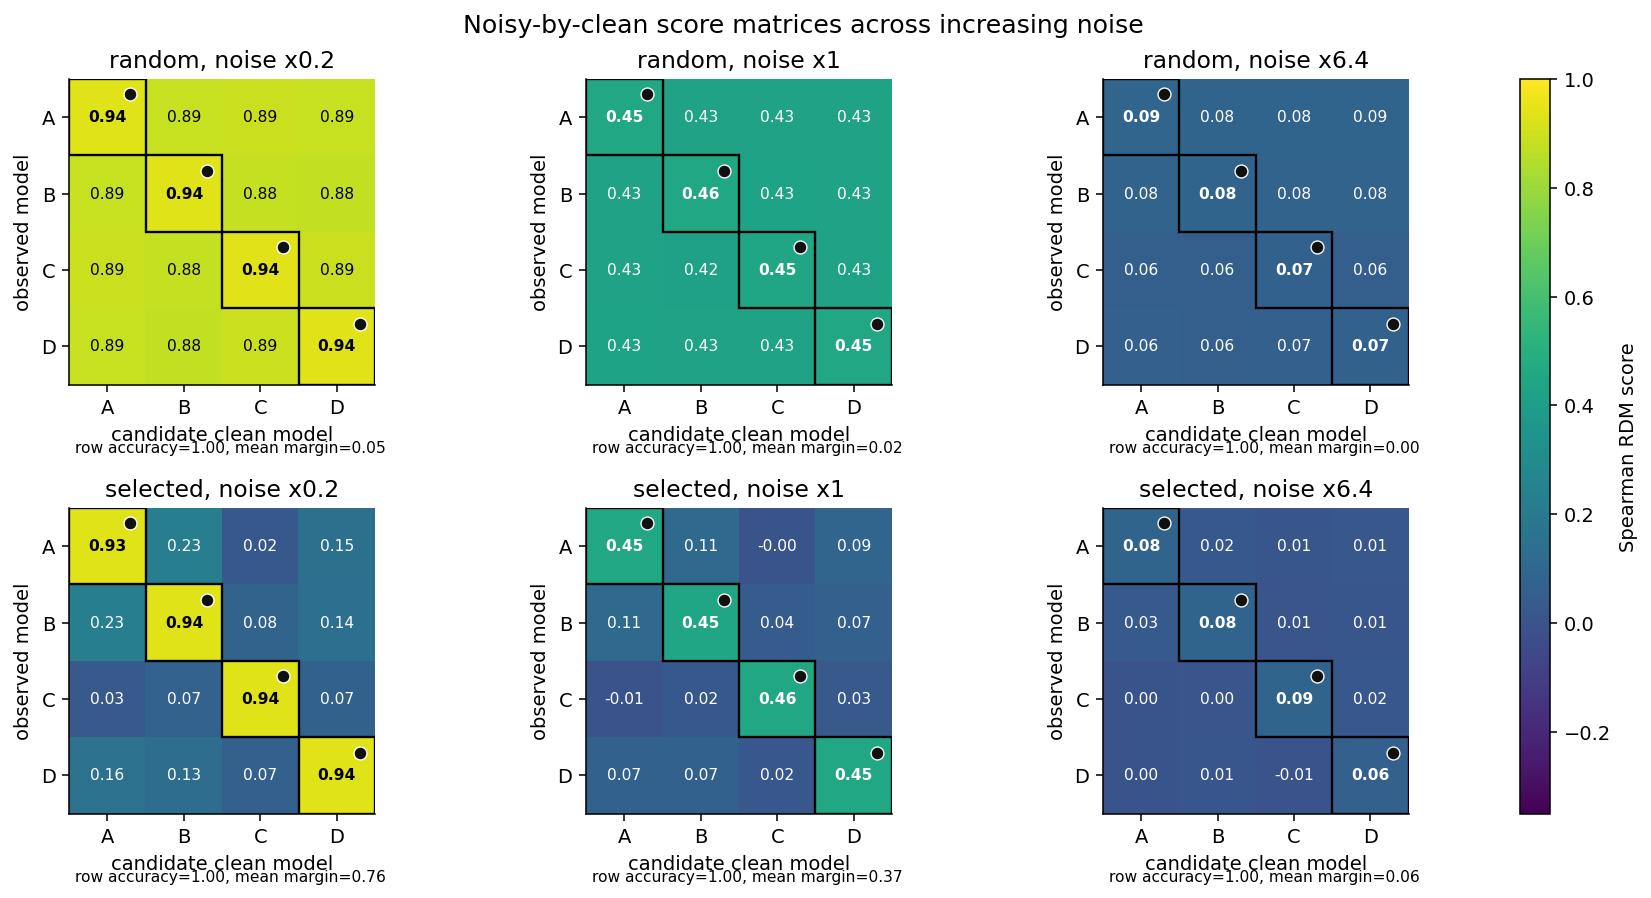

In [6]:
progression_mults = [0.20, 1.00, 6.40]
progression_matrices = {"random": {}, "selected": {}}
for subset in ["random", "selected"]:
    rdms = rdms_by_subset[subset]
    for noise_mult in progression_mults:
        progression_matrices[subset][noise_mult] = compute_noised_correlation_matrices(
            rdms,
            nbc_base_noise_stds[subset],
            CORR_TYPE,
            n_noise_samples=32,
            noise_multiplier=noise_mult,
            orientation="noisy_by_clean",
            generator=torch.Generator(device=device).manual_seed(1400 + int(noise_mult * 100) + (subset == "selected")),
        ).mean(dim=0).cpu().numpy()

fig = plt.figure(figsize=(12.0, 6.3), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.06])
axes = [[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(2)]
cbar_ax = fig.add_subplot(gs[:, 3])
for row, subset in enumerate(["random", "selected"]):
    for col, noise_mult in enumerate(progression_mults):
        ax = axes[row][col]
        matrix = progression_matrices[subset][noise_mult]
        im = plot_score_matrix(
            ax,
            matrix,
            f"{subset}, noise x{noise_mult:g}",
            "candidate clean model",
            "observed model",
            vmin=-0.35,
            vmax=1.0,
            cmap="viridis",
            show_winners=True,
        )
        acc = row_accuracy(matrix)
        mean_margin = row_margins(matrix).mean()
        ax.text(
            0.02,
            -0.22,
            f"row accuracy={acc:.2f}, mean margin={mean_margin:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            ha="left",
        )
fig.colorbar(im, cax=cbar_ax, label="Spearman RDM score")
fig.suptitle("Noisy-by-clean score matrices across increasing noise", fontsize=13)
plt.show()

## Method 2: teacher/student recovery

Teacher/student recovery adds a fitted readout step before scoring.

Read the score matrices row by row:

- the row is the teacher model that generated noisy response targets;
- the columns are candidate student models after each student has fit a ridge readout to the teacher;
- the diagonal is correct if the teacher's own model wins after the refit;
- a negative margin means the diagonal cell is lower than at least one off-diagonal cell in that row.

This method is stricter than noisy-by-clean because a candidate can win either because its representation is intrinsically close to the teacher or because the finite noisy refit made it predict that teacher's held-out RDM better.

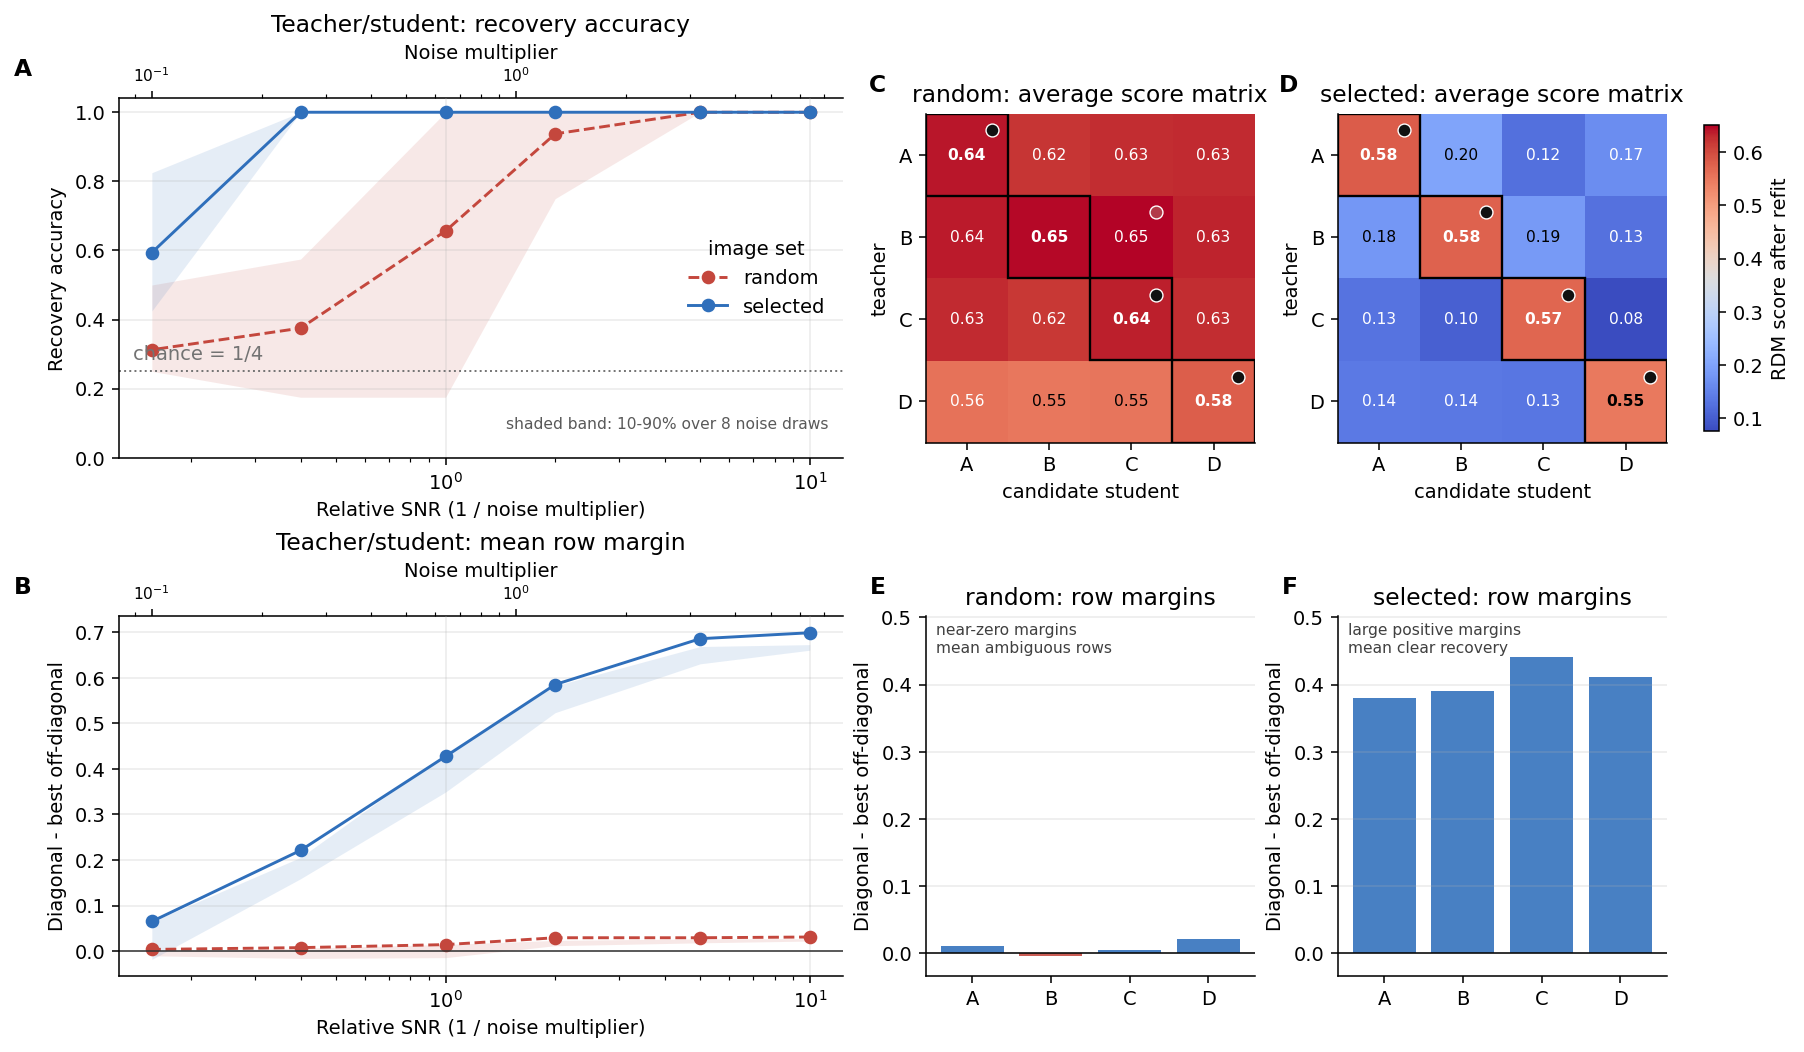

In [7]:
alpha = 1.0
candidate_ops = {}
for candidate in MODEL_NAMES:
    x_train, x_val, x_selected, x_random = standardize_from_train(
        toy_features["refit"][candidate][:n_refit_train],
        toy_features["refit"][candidate][n_refit_train:],
        toy_features["selected"][candidate],
        toy_features["random"][candidate],
        scale_by_sqrt_features=True,
    )
    candidate_ops[candidate] = ridge_ops_for_eval_sets(
        x_train,
        x_val,
        {"selected": x_selected, "random": x_random},
        [alpha],
    )[alpha][1]

teacher_targets = {}
for teacher in MODEL_NAMES:
    teacher_targets[teacher] = {}
    y_train, y_val, y_selected, y_random = standardize_from_train(
        toy_features["refit"][teacher][:n_refit_train],
        toy_features["refit"][teacher][n_refit_train:],
        toy_features["selected"][teacher],
        toy_features["random"][teacher],
    )
    teacher_targets[teacher]["train"] = y_train
    teacher_targets[teacher]["val"] = y_val
    teacher_targets[teacher]["selected"] = y_selected
    teacher_targets[teacher]["random"] = y_random

# The validation split is kept because the production helper API exposes it.
# This toy notebook fixes alpha so the refit mechanism stays visually simple.
ts_noise_samples = 8
ts_accuracy = {"random": [], "selected": []}
ts_margin = {"random": [], "selected": []}
ts_accuracy_samples = {"random": [], "selected": []}
ts_margin_samples = {"random": [], "selected": []}
ts_matrices_at_one = {}

for noise_mult in NOISE_MULTS:
    response_noise_std = response_noise_std_from_mode(float(noise_mult), BASE_NOISE_CEILING, "rdm_analytic")
    score_samples = {"random": [], "selected": []}
    for sample_idx in range(ts_noise_samples):
        sample_rng = np.random.default_rng(5000 + sample_idx + int(round(noise_mult * 100)))
        matrices = {
            "random": np.zeros((N_MODELS, N_MODELS), dtype=np.float32),
            "selected": np.zeros((N_MODELS, N_MODELS), dtype=np.float32),
        }
        for teacher_idx, teacher in enumerate(MODEL_NAMES):
            y_train = teacher_targets[teacher]["train"] + sample_rng.normal(
                0, response_noise_std, teacher_targets[teacher]["train"].shape
            ).astype(np.float32)
            for subset in ["selected", "random"]:
                noisy_teacher_eval = teacher_targets[teacher][subset] + sample_rng.normal(
                    0, response_noise_std, teacher_targets[teacher][subset].shape
                ).astype(np.float32)
                noisy_teacher_rdm = get_rdm_vector_np(noisy_teacher_eval, METRIC, device=device)
                for candidate_idx, candidate in enumerate(MODEL_NAMES):
                    pred = candidate_ops[candidate][subset] @ y_train
                    pred_rdm = get_rdm_vector_np(pred, METRIC, device=device)
                    matrices[subset][teacher_idx, candidate_idx] = calculate_correlation_value(
                        pred_rdm, noisy_teacher_rdm, CORR_TYPE, device=device
                    )
        for subset in ["selected", "random"]:
            score_samples[subset].append(matrices[subset])
    for subset in ["selected", "random"]:
        sample_stack = np.stack(score_samples[subset])
        score_tensor = torch.as_tensor(sample_stack, dtype=torch.float32)
        metrics = model_discriminability(score_tensor)
        ts_accuracy[subset].append(1.0 - float(metrics["non_parametric_multiclass_error_prob"]))
        ts_margin[subset].append(float(metrics["mean_margin"]))
        ts_accuracy_samples[subset].append([row_accuracy(m) for m in sample_stack])
        ts_margin_samples[subset].append([row_margins(m).mean() for m in sample_stack])
        if np.isclose(noise_mult, 1.0):
            ts_matrices_at_one[subset] = score_tensor.mean(dim=0).numpy()

ts_plot_results = {
    subset: {"accuracy": np.asarray(ts_accuracy[subset]), "margin": np.asarray(ts_margin[subset])}
    for subset in ["random", "selected"]
}

fig = plt.figure(figsize=(12.8, 7.4), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1.1, 1.1, 1.0, 1.0])
ax_acc = fig.add_subplot(gs[0, :2])
ax_margin = fig.add_subplot(gs[1, :2])
mat_axes = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])]
bar_axes = [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3], sharey=None)]

plot_recovery_curves(ax_acc, ax_margin, ts_plot_results, title_prefix="Teacher/student")
for subset in ["random", "selected"]:
    color = SUBSET_COLORS[subset]
    acc_samples = np.asarray(ts_accuracy_samples[subset], dtype=float)
    margin_samples = np.asarray(ts_margin_samples[subset], dtype=float)
    acc_low, acc_high = np.percentile(acc_samples, [10, 90], axis=1)
    margin_low, margin_high = np.percentile(margin_samples, [10, 90], axis=1)
    ax_acc.fill_between(RELATIVE_SNR, acc_low, acc_high, color=color, alpha=0.12, linewidth=0)
    ax_margin.fill_between(RELATIVE_SNR, margin_low, margin_high, color=color, alpha=0.12, linewidth=0)
ax_acc.text(0.98, 0.08, f"shaded band: 10-90% over {ts_noise_samples} noise draws", transform=ax_acc.transAxes, ha="right", fontsize=8, color="0.35")
label_panel(ax_acc, "A")
label_panel(ax_margin, "B")

vmin = min(float(np.nanmin(m)) for m in ts_matrices_at_one.values())
vmax = max(float(np.nanmax(m)) for m in ts_matrices_at_one.values())
for panel, ax, subset in zip(["C", "D"], mat_axes, ["random", "selected"]):
    matrix = ts_matrices_at_one[subset]
    im = plot_score_matrix(
        ax,
        matrix,
        f"{subset}: average score matrix",
        "candidate student",
        "teacher",
        vmin=vmin,
        vmax=vmax,
        cmap="coolwarm",
        show_winners=True,
    )
    label_panel(ax, panel)
fig.colorbar(im, ax=mat_axes, shrink=0.85, label="RDM score after refit")

all_margins = np.concatenate([row_margins(ts_matrices_at_one[subset]) for subset in ["random", "selected"]])
ymin = min(-0.02, float(all_margins.min()) - 0.03)
ymax = float(all_margins.max()) + 0.06
for panel, ax, subset in zip(["E", "F"], bar_axes, ["random", "selected"]):
    matrix = ts_matrices_at_one[subset]
    margins = row_margins(matrix)
    winners = np.nanargmax(matrix, axis=1)
    colors = [SELECTED_COLOR if winners[i] == i else RANDOM_COLOR for i in range(N_MODELS)]
    ax.bar(MODEL_NAMES, margins, color=colors, alpha=0.88)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{subset}: row margins")
    ax.set_ylabel("Diagonal - best off-diagonal")
    ax.grid(axis="y", alpha=0.25)
    label_panel(ax, panel)
bar_axes[0].text(0.03, 0.90, "near-zero margins\nmean ambiguous rows", transform=bar_axes[0].transAxes, fontsize=8, color="0.25")
bar_axes[1].text(0.03, 0.90, "large positive margins\nmean clear recovery", transform=bar_axes[1].transAxes, fontsize=8, color="0.25")
plt.show()

### Same row, different operation

The score matrices look similar because both have rows, columns, diagonals, and row winners. But a bar in the two methods is not the same kind of quantity.

The next figure uses the same source row (`A`) and the selected image set at noise multiplier `1.0`:

- in noisy-by-clean, each bar compares noisy `A` directly with a fixed clean candidate RDM;
- in teacher/student, each bar first fits a student-specific readout to teacher `A`, then scores held-out predicted RDMs.

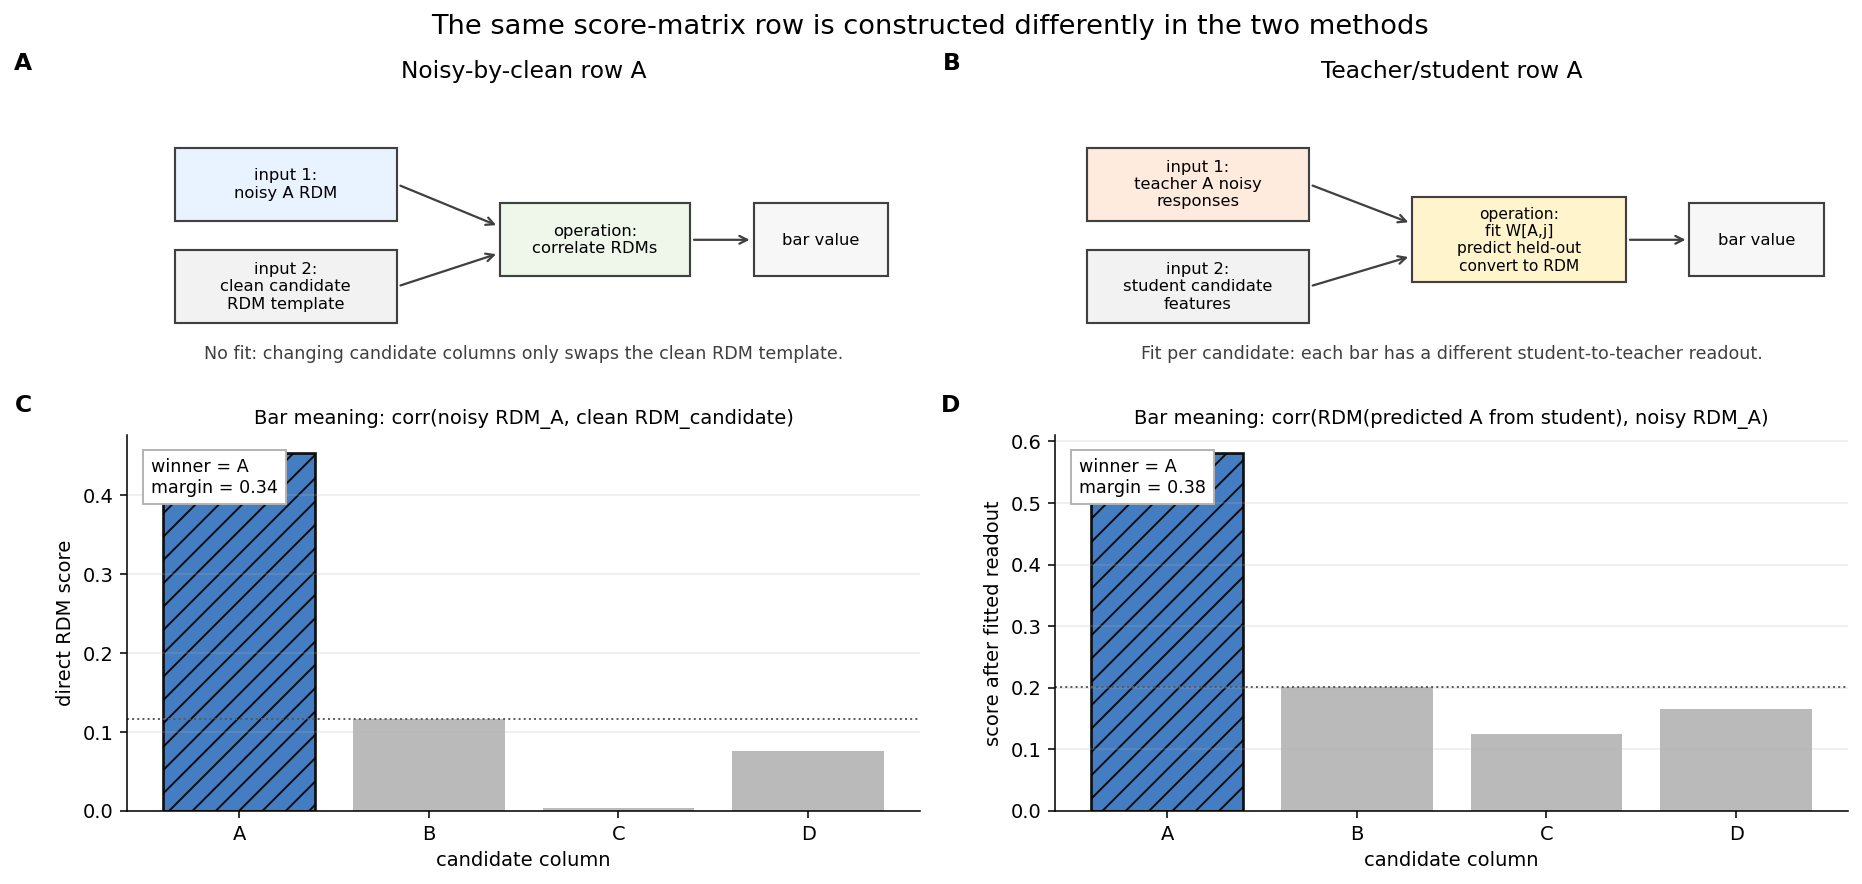

In [8]:
row_idx = 0
subset = "selected"
nbc_row = nbc_score_matrices[subset][row_idx]
ts_row = ts_matrices_at_one[subset][row_idx]

fig = plt.figure(figsize=(13.2, 6.2), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[0.78, 1.0])
pipe_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
bar_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]


def mini_box(ax, x, y, w, h, text, fc, *, fs=8.4):
    ax.add_patch(mpatches.Rectangle((x, y), w, h, facecolor=fc, edgecolor="0.25", linewidth=1.1))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs)


def mini_arrow(ax, start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", linewidth=1.15, color="0.25"))

for ax in pipe_axes:
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Method 1 mini-pipeline.
ax = pipe_axes[0]
mini_box(ax, 0.06, 0.55, 0.28, 0.25, "input 1:\nnoisy A RDM", "#E9F2FF")
mini_box(ax, 0.06, 0.20, 0.28, 0.25, "input 2:\nclean candidate\nRDM template", "#F2F2F2")
mini_box(ax, 0.47, 0.36, 0.24, 0.25, "operation:\ncorrelate RDMs", "#EEF7EA")
mini_box(ax, 0.79, 0.36, 0.17, 0.25, "bar value", "#F7F7F7")
mini_arrow(ax, (0.34, 0.675), (0.47, 0.53))
mini_arrow(ax, (0.34, 0.325), (0.47, 0.44))
mini_arrow(ax, (0.71, 0.485), (0.79, 0.485))
ax.text(0.50, 0.08, "No fit: changing candidate columns only swaps the clean RDM template.", ha="center", fontsize=9, color="0.25")
ax.set_title("Noisy-by-clean row A", fontsize=12)
label_panel(ax, "A")

# Method 2 mini-pipeline.
ax = pipe_axes[1]
mini_box(ax, 0.04, 0.55, 0.28, 0.25, "input 1:\nteacher A noisy\nresponses", "#FFEBDD")
mini_box(ax, 0.04, 0.20, 0.28, 0.25, "input 2:\nstudent candidate\nfeatures", "#F2F2F2")
mini_box(ax, 0.45, 0.34, 0.27, 0.29, "operation:\nfit W[A,j]\npredict held-out\nconvert to RDM", "#FFF4CC", fs=8.0)
mini_box(ax, 0.80, 0.36, 0.17, 0.25, "bar value", "#F7F7F7")
mini_arrow(ax, (0.32, 0.675), (0.45, 0.54))
mini_arrow(ax, (0.32, 0.325), (0.45, 0.43))
mini_arrow(ax, (0.72, 0.485), (0.80, 0.485))
ax.text(0.50, 0.08, "Fit per candidate: each bar has a different student-to-teacher readout.", ha="center", fontsize=9, color="0.25")
ax.set_title("Teacher/student row A", fontsize=12)
label_panel(ax, "B")

rows = [nbc_row, ts_row]
titles = [
    "Bar meaning: corr(noisy RDM_A, clean RDM_candidate)",
    "Bar meaning: corr(RDM(predicted A from student), noisy RDM_A)",
]
ylabels = ["direct RDM score", "score after fitted readout"]
for ax, scores, title, ylabel, panel in zip(bar_axes, rows, titles, ylabels, ["C", "D"]):
    winner = int(np.nanargmax(scores))
    best_off_idx = int(np.argmax(np.where(np.arange(N_MODELS) == row_idx, -np.inf, scores)))
    margin = float(scores[row_idx] - scores[best_off_idx])
    colors = ["0.70"] * N_MODELS
    colors[row_idx] = SELECTED_COLOR
    bars = ax.bar(MODEL_NAMES, scores, color=colors, alpha=0.90)
    bars[row_idx].set_edgecolor("black")
    bars[row_idx].set_linewidth(1.4)
    bars[winner].set_hatch("//")
    ax.axhline(scores[best_off_idx], color="0.35", linestyle=":", linewidth=1)
    ax.text(
        0.03,
        0.94,
        f"winner = {MODEL_NAMES[winner]}\nmargin = {margin:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="0.7", pad=4),
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("candidate column")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    label_panel(ax, panel)
fig.suptitle("The same score-matrix row is constructed differently in the two methods", fontsize=14)
plt.show()

### Raw score is not the same as recovery

In teacher/student recovery, a random set can give high scores to many students at once. The next figure separates the diagonal score from the strongest wrong competitor. The gap, not the absolute height of the diagonal alone, determines recovery.

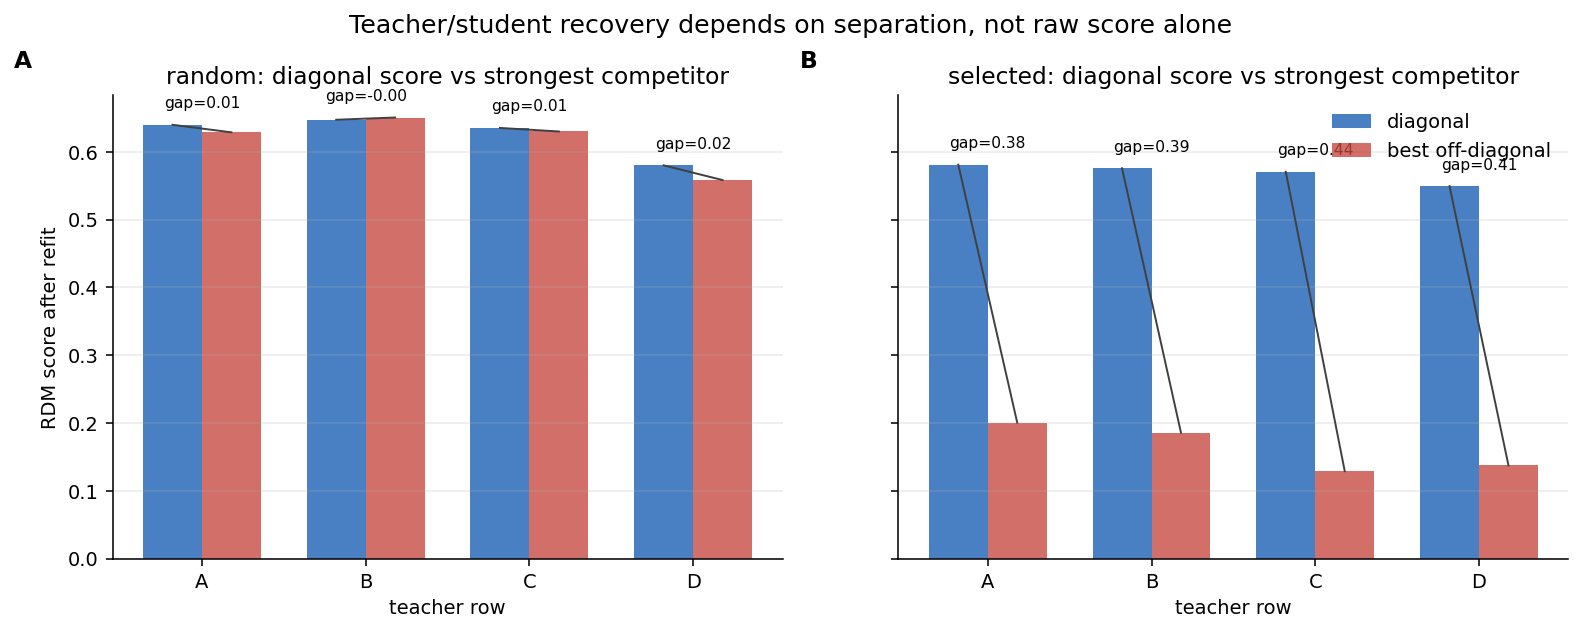

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4), constrained_layout=True, sharey=True)
bar_width = 0.36
x = np.arange(N_MODELS)
for panel, ax, subset in zip(["A", "B"], axes, ["random", "selected"]):
    matrix = ts_matrices_at_one[subset]
    diag = np.diag(matrix)
    best_off = np.asarray([np.max(np.delete(matrix[i], i)) for i in range(N_MODELS)])
    ax.bar(x - bar_width / 2, diag, bar_width, color=SELECTED_COLOR, alpha=0.88, label="diagonal")
    ax.bar(x + bar_width / 2, best_off, bar_width, color=RANDOM_COLOR, alpha=0.78, label="best off-diagonal")
    for i in range(N_MODELS):
        ax.plot([i - bar_width / 2, i + bar_width / 2], [diag[i], best_off[i]], color="0.25", linewidth=1)
        ax.text(i, max(diag[i], best_off[i]) + 0.025, f"gap={diag[i] - best_off[i]:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x, MODEL_NAMES)
    ax.set_title(f"{subset}: diagonal score vs strongest competitor")
    ax.set_xlabel("teacher row")
    ax.grid(axis="y", alpha=0.25)
    label_panel(ax, panel)
axes[0].set_ylabel("RDM score after refit")
axes[1].legend(frameon=False, loc="upper right")
fig.suptitle("Teacher/student recovery depends on separation, not raw score alone", fontsize=13)
plt.show()

## Direct method comparison

The final figure puts both methods on the same axes. This makes the main teaching point explicit: the selected set helps both methods, but teacher/student recovery is the stricter test because it includes a finite noisy refit before held-out RDM scoring.

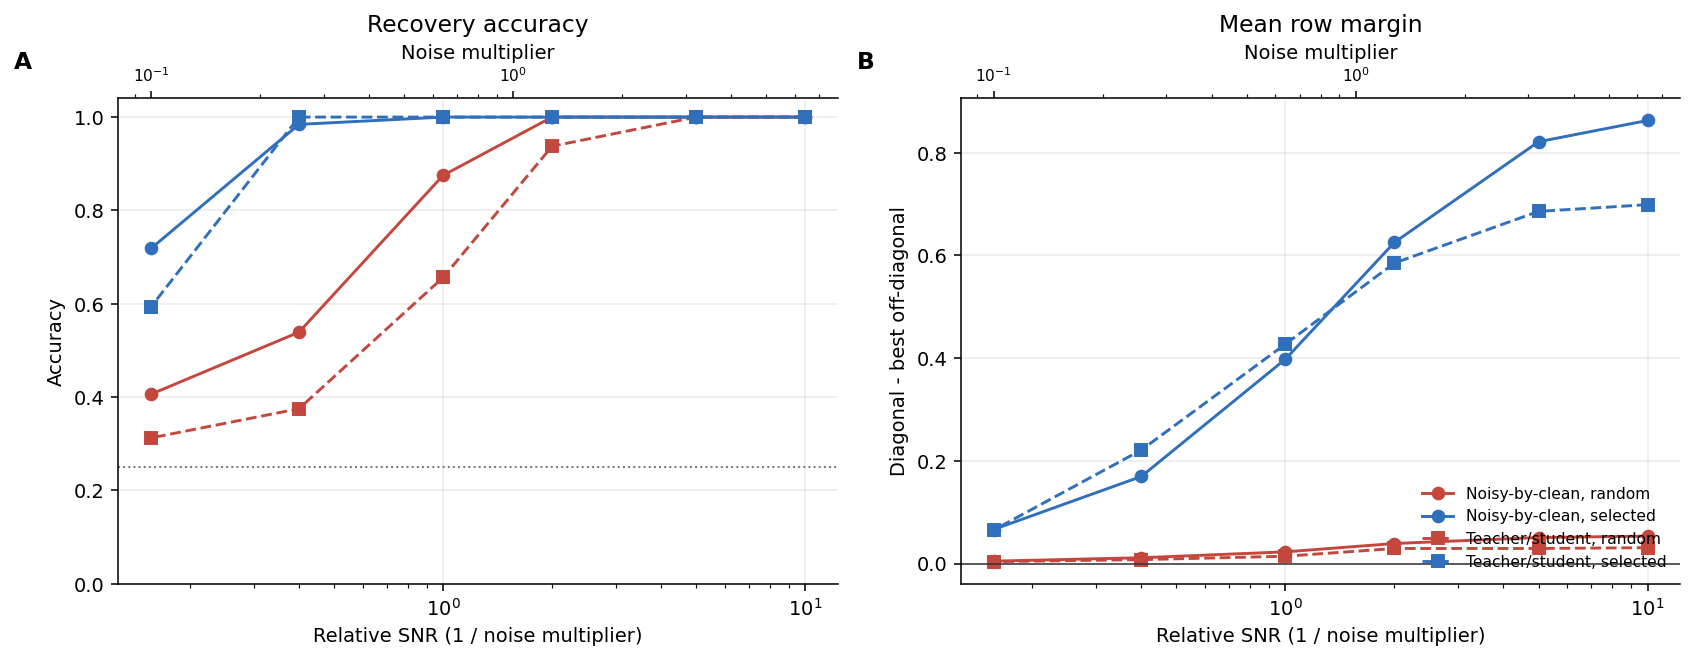

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), constrained_layout=True)
method_specs = [
    ("Noisy-by-clean", nbc_plot_results, "o", "-"),
    ("Teacher/student", ts_plot_results, "s", "--"),
]
for method_name, results, marker, method_line in method_specs:
    for subset in ["random", "selected"]:
        color = SUBSET_COLORS[subset]
        label = f"{method_name}, {subset}"
        axes[0].plot(RELATIVE_SNR, results[subset]["accuracy"], marker=marker, linestyle=method_line, color=color, label=label)
        axes[1].plot(RELATIVE_SNR, results[subset]["margin"], marker=marker, linestyle=method_line, color=color, label=label)

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Relative SNR (1 / noise multiplier)")
    add_noise_multiplier_axis(ax)
axes[0].set_title("Recovery accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.04)
axes[0].axhline(1 / N_MODELS, color=NEUTRAL_COLOR, linestyle=":", linewidth=1)
axes[1].set_title("Mean row margin")
axes[1].set_ylabel("Diagonal - best off-diagonal")
axes[1].axhline(0, color="0.2", linewidth=0.8)
axes[1].legend(frameon=False, fontsize=8, loc="lower right")
label_panel(axes[0], "A")
label_panel(axes[1], "B")
plt.show()

## Takeaways and limitations

- Noisy-by-clean recovery tests whether a noisy model RDM can be matched directly to the correct clean model RDM.
- Teacher/student recovery is stricter because every candidate student must first fit a noisy teacher response pattern and then generalize to held-out images.
- The selected toy image set helps because it reduces off-diagonal confusability while preserving the diagonal match.
- The row margin is the most useful diagnostic: high raw scores can still be ambiguous if wrong candidates score nearly as high as the diagonal.
- This notebook is a compact didactic approximation. The production teacher/student figure can differ because it uses the full model roster, full image pools, production noise calibration, more samples, and the full refit/evaluation configuration.